In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

In [ ]:
df = pd.read_csv('bike.csv')
df.head()

,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,cnt
0,1,1/1/2011,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0,16
1,2,1/1/2011,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0,40
2,3,1/1/2011,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0,32
3,4,1/1/2011,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0,13
4,5,1/1/2011,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0,1


In [ ]:
for column in df.columns:
  print(f'колонка: {column}')

колонка: instant
колонка: dteday
колонка: season
колонка: yr
колонка: mnth
колонка: hr
колонка: holiday
колонка: weekday
колонка: workingday
колонка: weathersit
колонка: temp
колонка: atemp
колонка: hum
колонка: windspeed
колонка: cnt


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17379 entries, 0 to 17378
Data columns (total 15 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     17379 non-null  int64  
 1   dteday      17379 non-null  object 
 2   season      17379 non-null  int64  
 3   yr          17379 non-null  int64  
 4   mnth        17379 non-null  int64  
 5   hr          17379 non-null  int64  
 6   holiday     17379 non-null  int64  
 7   weekday     17379 non-null  int64  
 8   workingday  17379 non-null  int64  
 9   weathersit  17379 non-null  int64  
 10  temp        17379 non-null  float64
 11  atemp       17379 non-null  float64
 12  hum         17379 non-null  float64
 13  windspeed   17379 non-null  float64
 14  cnt         17379 non-null  int64  
dtypes: float64(4), int64(10), object(1)
memory usage: 2.0+ MB


In [ ]:
print(df.isnull().sum())

instant       0
dteday        0
season        0
yr            0
mnth          0
hr            0
holiday       0
weekday       0
workingday    0
weathersit    0
temp          0
atemp         0
hum           0
windspeed     0
cnt           0
dtype: int64


In [ ]:
np.random.seed(42)
df_test_nan = df.copy()
df_test_nan.loc[np.random.choice(df_test_nan.index, size=5, replace=True), 'instant'] = np.nan

In [ ]:
print(df_test_nan.isnull().sum())

instant       5
dteday        0
season        0
yr            0
mnth          0
hr            0
holiday       0
weekday       0
workingday    0
weathersit    0
temp          0
atemp         0
hum           0
windspeed     0
cnt           0
dtype: int64


In [ ]:
df_drop = df_test_nan.dropna()
print("\n# Удаление строк с пропусками")
print(df.isnull().sum())


# Удаление строк с пропусками
instant       0
dteday        0
season        0
yr            0
mnth          0
hr            0
holiday       0
weekday       0
workingday    0
weathersit    0
temp          0
atemp         0
hum           0
windspeed     0
cnt           0
dtype: int64


In [ ]:
df_median = df_test_nan.copy()
df_median.instant = df_median.instant.fillna(df_median.instant.median())

print("\n# Заполнение пропусков медианой")
print(df_median.isnull().sum())


# Заполнение пропусков медианой
instant       0
dteday        0
season        0
yr            0
mnth          0
hr            0
holiday       0
weekday       0
workingday    0
weathersit    0
temp          0
atemp         0
hum           0
windspeed     0
cnt           0
dtype: int64


In [ ]:
df.instant.mode()

,instant
0,1
1,2
2,3
3,4
4,5
...,...
17374,17375
17375,17376
17376,17377
17377,17378


In [ ]:
df['malo'] = np.where(df['cnt'] <= 10, 1, 0).astype(int)
df.columns

Index(['instant', 'dteday', 'season', 'yr', 'mnth', 'hr', 'holiday', 'weekday',
       'workingday', 'weathersit', 'temp', 'atemp', 'hum', 'windspeed', 'cnt',
       'malo'],
      dtype='object')

In [ ]:
Y = df['malo']
X = df.drop('malo', axis=1)
X = X.drop('cnt', axis=1)
X = X.drop('yr', axis=1)
X = X.drop('hr', axis=1)
X = X.drop('workingday', axis=1)
X = X.drop('weathersit', axis=1)
X = X.drop('instant', axis=1)
X = X.drop('dteday', axis=1)

In [ ]:
numeric_cols = X.select_dtypes(include=['float64'])

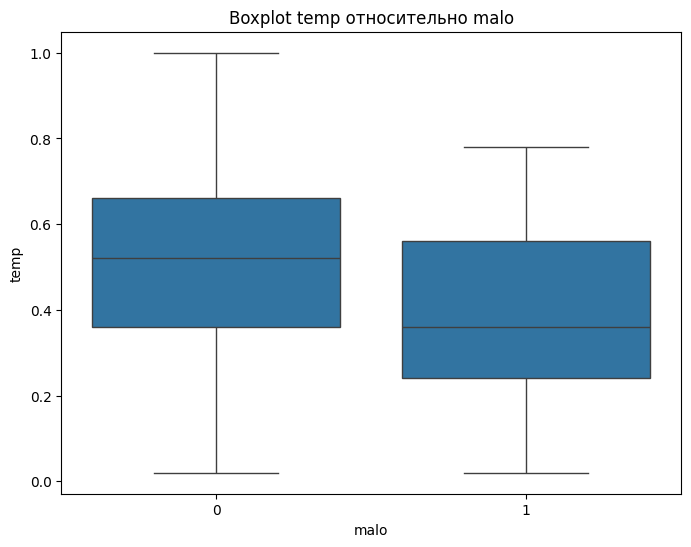

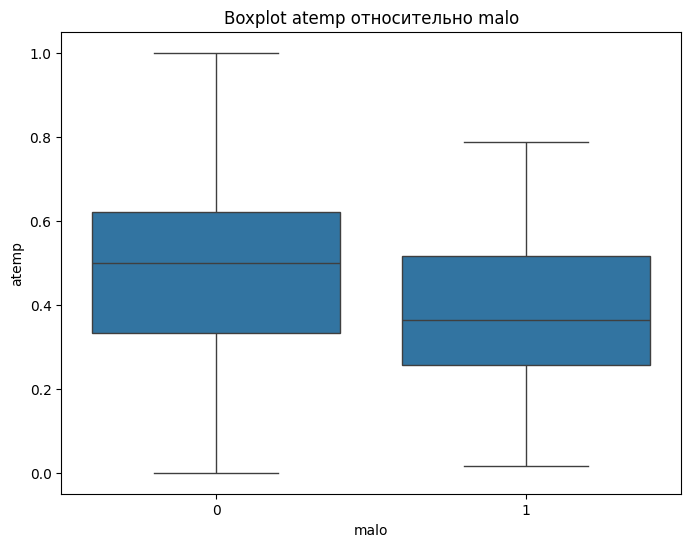

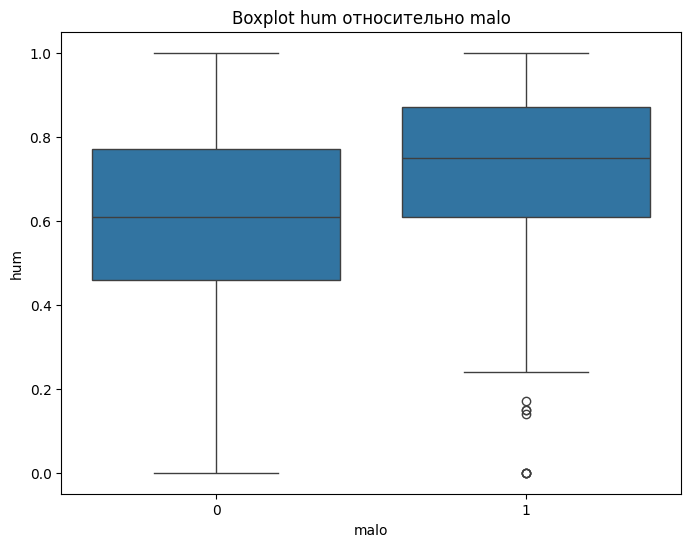

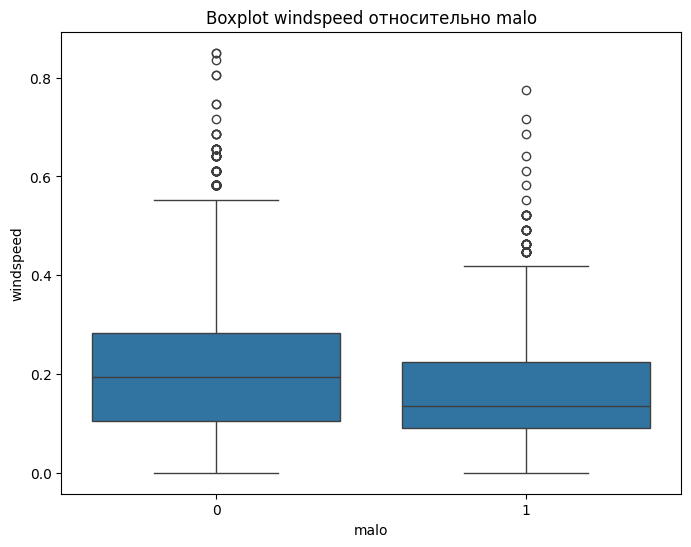

In [ ]:
for col in numeric_cols:
    plt.figure(figsize=(8, 6))
    sns.boxplot(x='malo', y=col, data=df)
    plt.title(f'Boxplot {col} относительно malo')
    plt.show()

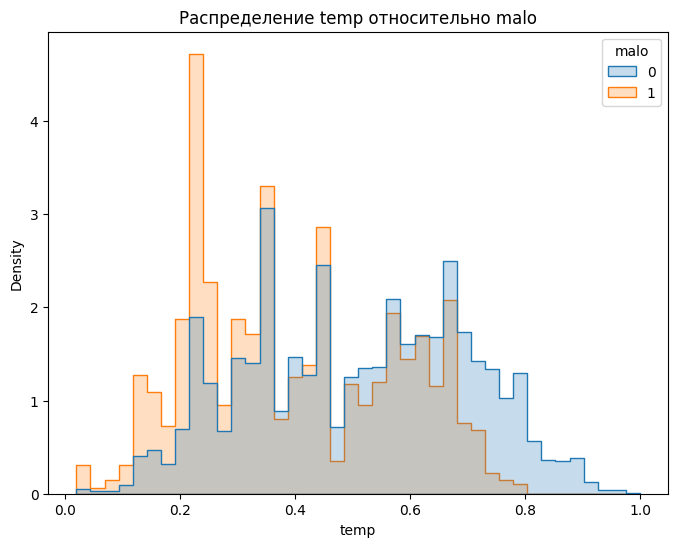

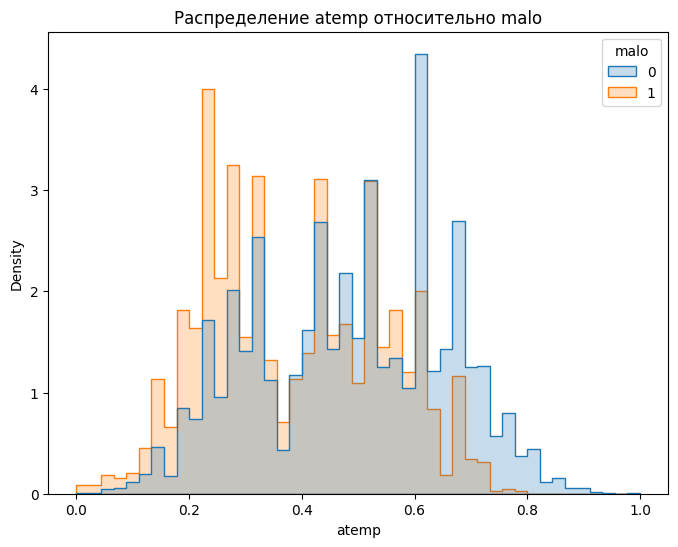

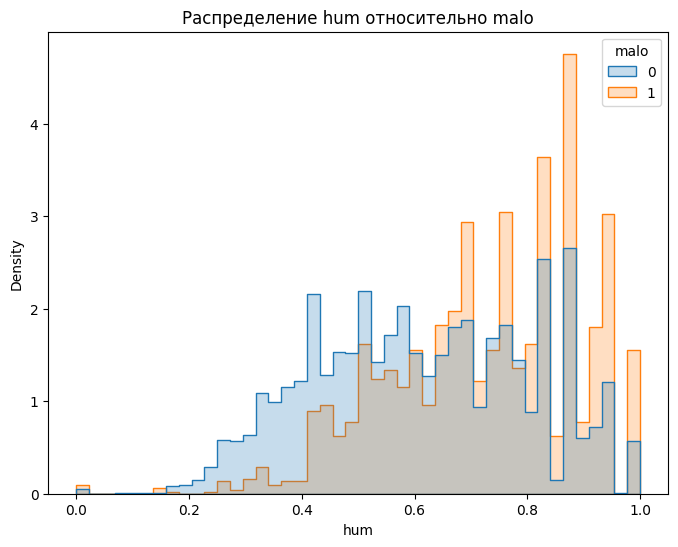

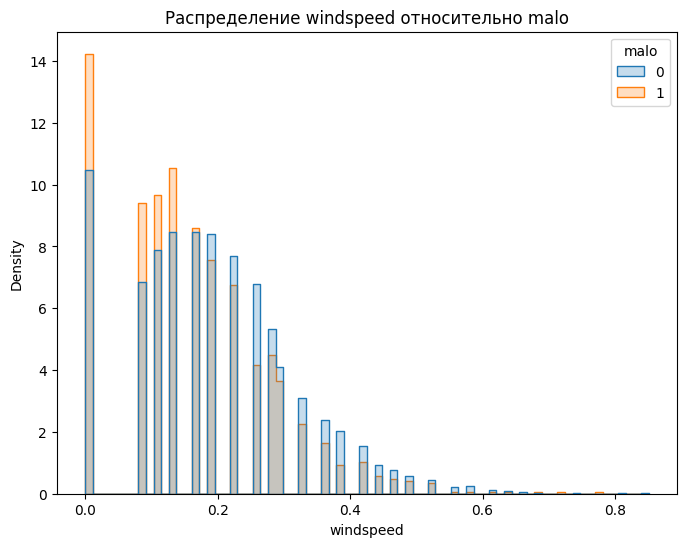

In [ ]:
for col in numeric_cols:
    plt.figure(figsize=(8, 6))
    sns.histplot(data=df, x=col, hue='malo', element="step", stat="density", common_norm=False)
    plt.title(f'Распределение {col} относительно malo')
    plt.show()

Исходя из графика распределения season относительно malo, мы можем увидеть, что в первом сезоне кол-во арендованных достаточно мало, а в других сезонах наоборот достаточно велико.

In [ ]:
desc_stats_numeric = df.groupby('malo')[df.select_dtypes(include=[np.number]).columns].describe()
desc_stats_categorical = df.groupby('malo')[df.select_dtypes(include=['object']).columns].describe()


In [ ]:
for col in numeric_cols:
    print(f"Описательная статистика для {col}:\n")
    print(df.groupby('malo')[col].describe())
    print("\n" + "="*50 + "\n")

Описательная статистика для temp:

        count      mean       std   min   25%   50%   75%   max
malo                                                           
0     15399.0  0.509847  0.190893  0.02  0.36  0.52  0.66  1.00
1      1980.0  0.396970  0.175396  0.02  0.24  0.36  0.56  0.78


Описательная статистика для atemp:

        count      mean       std     min     25%     50%     75%     max
malo                                                                     
0     15399.0  0.487139  0.170363  0.0000  0.3333  0.5000  0.6212  1.0000
1      1980.0  0.387399  0.157124  0.0152  0.2576  0.3636  0.5152  0.7879


Описательная статистика для hum:

        count      mean       std  min   25%   50%   75%  max
malo                                                         
0     15399.0  0.614494  0.192196  0.0  0.46  0.61  0.77  1.0
1      1980.0  0.726268  0.168419  0.0  0.61  0.75  0.87  1.0


Описательная статистика для windspeed:

        count      mean       std  min     25%   

In [ ]:
print("\nКатегориальные переменные:")
desc_stats_categorical


Категориальные переменные:


dteday                        
      count unique         top freq
malo                               
0     15399    731   6/23/2012   24
1      1980    687  12/26/2012    9

**ПОМЕНЯТЬ**

1. Fixed Acidity:

    Среднее значение фиксированной кислотности у вина с качеством ниже 7 (is_best_wine = 0) составляет 7.25, что чуть выше, чем у вин с качеством 7 и выше (is_best_wine = 1), где среднее значение равно 7.09.
    Разброс (std) в обеих группах примерно одинаковый (~1.28 и 1.34), что говорит о схожей вариативности кислотности среди разных вин.
    В обоих случаях минимальное значение около 3.8, максимальные значения около 15.9 и 15.6, что указывает на схожие диапазоны фиксированной кислотности между категориями.

2. Volatile Acidity:

    У лучших вин (is_best_wine = 1) средняя летучая кислотность ниже (0.289) по сравнению с менее качественными винами (is_best_wine = 0), где она составляет 0.352. Это может свидетельствовать о том, что летучая кислотность сильнее снижает качество вина.
    Стандартное отклонение меньше у лучших вин, что говорит о более однородных показателях летучей кислотности среди качественных вин.

3. Citric Acid:

    У лучших вин среднее содержание лимонной кислоты чуть выше (0.335 против 0.315).
    У обоих классов наблюдается низкая вариативность содержания лимонной кислоты, и медианные значения довольно близки.

4. Residual Sugar:

    В среднем, остаточный сахар у менее качественных вин выше (5.59) по сравнению с лучшими винами (4.83). Это может указывать на тенденцию того, что менее сладкие вина имеют более высокую оценку.
    У обоих типов вина наблюдаются существенные выбросы в максимальных значениях остаточного сахара.

5. Chlorides:

    Лучшие вина имеют меньшее среднее содержание хлоридов (0.0445 против 0.0588), что может указывать на отрицательное влияние хлоридов на качество вина.
    Также наблюдается меньшее стандартное отклонение среди лучших вин, что указывает на более однородный состав по хлоридам.

6. Free Sulfur Dioxide:

    Среднее содержание свободного диоксида серы не сильно отличается между группами (30.4 и 31.0), что свидетельствует о том, что этот показатель слабо коррелирует с качеством вина.
    У менее качественных вин наблюдается более высокий разброс значений.

7. Total Sulfur Dioxide:

    Лучшие вина содержат меньше общего диоксида серы (109.89 против 117.18), что может указывать на негативное влияние высокого содержания серы на восприятие вина.
    У менее качественных вин также выше максимальные значения общего содержания диоксида серы.

8. Density:

    Лучшие вина имеют меньшую плотность в среднем (0.993 против 0.995), что может свидетельствовать о лучшем качестве.
    Стандартное отклонение плотности невелико, а диапазон значений у обоих классов вин узкий, что указывает на стабильность этого показателя.

9. pH:

    Значения pH почти идентичны в обеих группах (3.216 против 3.227), что указывает на отсутствие сильного влияния уровня pH на качество вина.

10. Sulphates:

    Лучшие вина имеют чуть более высокое среднее содержание сульфатов (0.541 против 0.528). Однако разница невелика, что может указывать на слабую зависимость между содержанием сульфатов и качеством.
    Разброс значений также схожий, что говорит о стабильности этого показателя для обеих категорий.

11. Alcohol:

    Значительное различие в содержании алкоголя: лучшие вина имеют более высокое среднее содержание алкоголя (11.43 против 10.26). Это указывает на тенденцию, что вина с более высоким содержанием алкоголя чаще оцениваются выше.
    В то же время у лучших вин наблюдается чуть больший разброс по содержанию алкоголя.

12. Quality:

    Как и ожидалось, вина с is_best_wine = 1 имеют среднее значение качества около 7, в то время как вина с is_best_wine = 0 — 5.49.
    Важно отметить, что у лучших вин разброс по качеству ниже, что указывает на более стабильное восприятие.

Вывод:

На основе представленных данных можно сделать выводы о ключевых характеристиках, которые влияют на качество вина. В частности:

    Более качественные вина имеют меньшее содержание летучих кислот, хлоридов и общего диоксида серы.
    Лучшие ви

    на содержат больше алкоголя, что, возможно, положительно сказывается на восприятии.
    Несмотря на различия, такие параметры, как pH, сульфаты и свободный диоксид серы, имеют незначительное влияние на итоговое качество.



In [ ]:
df[df.select_dtypes(include=[np.number]).columns].corr()

,instant,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,cnt,malo
instant,1.000000,0.404046,0.866014,0.489164,-0.004775,0.014723,0.001357,-0.003416,-0.014198,0.136178,0.137615,0.009577,-0.074505,0.278379,-0.070953
season,0.404046,1.000000,-0.010742,0.830386,-0.006117,-0.009585,-0.002335,0.013743,-0.014524,0.312025,0.319380,0.150625,-0.149773,0.178056,-0.069576
yr,0.866014,-0.010742,1.000000,-0.010473,-0.003867,0.006692,-0.004485,-0.002196,-0.019157,0.040913,0.039222,-0.083546,-0.008740,0.250495,-0.052908
mnth,0.489164,0.830386,-0.010473,1.000000,-0.005772,0.018430,0.010400,-0.003477,0.005400,0.201691,0.208096,0.164411,-0.135386,0.120638,-0.049232
hr,-0.004775,-0.006117,-0.003867,-0.005772,1.000000,0.000479,-0.003498,0.002285,-0.020203,0.137603,0.133750,-0.276498,0.137252,0.394071,-0.419071
holiday,0.014723,-0.009585,0.006692,0.018430,0.000479,1.000000,-0.102088,-0.252471,-0.017036,-0.027340,-0.030973,-0.010588,0.003988,-0.030927,-0.001046
weekday,0.001357,-0.002335,-0.004485,0.010400,-0.003498,-0.102088,1.000000,0.035955,0.003311,-0.001795,-0.008821,-0.037158,0.011502,0.026900,-0.017001
workingday,-0.003416,0.013743,-0.002196,-0.003477,0.002285,-0.252471,0.035955,1.000000,0.044672,0.055390,0.054667,0.015688,-0.011830,0.030284,0.057672
weathersit,-0.014198,-0.014524,-0.019157,0.005400,-0.020203,-0.017036,0.003311,0.044672,1.000000,-0.102640,-0.105563,0.418130,0.026226,-0.142426,0.035107
temp,0.136178,0.312025,0.040913,0.201691,0.137603,-0.027340,-0.001795,0.055390,-0.102640,1.000000,0.987672,-0.069881,-0.023125,0.404772,-0.186259


**ПОМЕНЯТЬ**

Интерпретация:

    Коэффициент корреляции Пирсона показывает степень линейной связи между двумя переменными.

Описание корреляций для значимых признаков:

    Alcohol и Quality (0.444):
        Есть умеренная положительная корреляция между содержанием алкоголя и качеством вина. Это указывает на то, что вина с более высоким содержанием алкоголя чаще оцениваются выше. Этот признак может быть значимым для прогнозирования качества вина, поскольку он имеет достаточно сильную связь с целевой переменной.

    Alcohol и is_best_wine (0.390):
        Похожая корреляция наблюдается между содержанием алкоголя и принадлежностью вина к категории лучших (is_best_wine). Более высокое содержание алкоголя коррелирует с вероятностью, что вино будет оценено как "лучшее".

    Quality и is_best_wine (0.759):
        Как и ожидалось, очень высокая корреляция между качеством вина и принадлежностью к категории лучших вин. Это обусловлено тем, что признак is_best_wine напрямую основан на значении quality.

    Total Sulfur Dioxide и Free Sulfur Dioxide (0.720):
        Высокая корреляция между общим и свободным диоксидом серы. Это вполне ожидаемо, так как общий диоксид серы включает в себя свободную и связанную формы. В этом случае один из признаков может быть исключен для предотвращения избыточности информации в модели.

    Residual Sugar и Density (0.553):
        Средняя положительная корреляция между остаточным сахаром и плотностью вина. Более высокое содержание остаточного сахара увеличивает плотность вина, что логично, так как сахар увеличивает массу раствора. Этот признак также может вызвать мультиколлинеарность.

    Density и Alcohol (-0.687):
        Сильная отрицательная корреляция между плотностью и содержанием алкоголя. Вина с высоким содержанием алкоголя имеют меньшую плотность, что объясняется физическими свойствами спирта. Это важно учитывать при построении моделей, чтобы избежать мультиколлинеарности.

    Alcohol и Density (-0.686):
        Как уже упоминалось, это значительная отрицательная корреляция. В этом случае, возможно, стоит исключить один из этих признаков для предотвращения мультиколлинеарности.

Почему мультиколлинеарность это плохо?

Мультиколлинеарность возникает, когда два или более независимых признака сильно коррелируют друг с другом. Это приводит к нескольким проблемам:

    Переоценка значимости признаков:
        Когда признаки сильно коррелированы, модель может "перепутать" влияние каждого из них на целевую переменную, что приведет к ненадежным коэффициентам. Это затрудняет интерпретацию модели, поскольку сложно понять, какой из признаков действительно важен.

    Нестабильность модели:
        При наличии мультиколлинеарности небольшие изменения в данных могут привести к большим изменениям в коэффициентах модели. Это делает м

        одель нестабильной и менее устойчивой.

    Затруднение выбора значимых признаков:
        Модель может затрудняться при выделении важности отдельных признаков, если они сильно связаны друг с другом. Это может усложнить процесс отбора признаков и снизить точность модели.

    Увеличение дисперсии коэффициентов:
        Мультиколлинеарность увеличивает дисперсию оценок коэффициентов регрессии, что делает их менее надежными. В результате, некоторые признаки могут казаться незначимыми, хотя на самом деле они играют важную роль.


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

In [ ]:
categorical_features = X.select_dtypes(include=['object', 'int64']).columns.tolist()
print("Категориальные признаки:", categorical_features)

Категориальные признаки: ['season', 'mnth', 'holiday', 'weekday']


In [ ]:
X[categorical_features]

,season,mnth,holiday,weekday
0,1,1,0,6
1,1,1,0,6
2,1,1,0,6
3,1,1,0,6
4,1,1,0,6
...,...,...,...,...
17374,1,12,0,1
17375,1,12,0,1
17376,1,12,0,1
17377,1,12,0,1


In [ ]:
X_processed = X.copy()
X_processed = pd.get_dummies(X_processed, columns=categorical_features, drop_first=True)

In [ ]:
X_processed

,temp,atemp,hum,windspeed,season_2,season_3,season_4,mnth_2,mnth_3,mnth_4,...,mnth_10,mnth_11,mnth_12,holiday_1,weekday_1,weekday_2,weekday_3,weekday_4,weekday_5,weekday_6
0,0.24,0.2879,0.81,0.0000,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True
1,0.22,0.2727,0.80,0.0000,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True
2,0.22,0.2727,0.80,0.0000,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True
3,0.24,0.2879,0.75,0.0000,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True
4,0.24,0.2879,0.75,0.0000,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17374,0.26,0.2576,0.60,0.1642,False,False,False,False,False,False,...,False,False,True,False,True,False,False,False,False,False
17375,0.26,0.2576,0.60,0.1642,False,False,False,False,False,False,...,False,False,True,False,True,False,False,False,False,False
17376,0.26,0.2576,0.60,0.1642,False,False,False,False,False,False,...,False,False,True,False,True,False,False,False,False,False
17377,0.26,0.2727,0.56,0.1343,False,False,False,False,False,False,...,False,False,True,False,True,False,False,False,False,False


In [ ]:
def train_and_evaluate(X, Y):
    X_train, X_test, Y_train, Y_test = train_test_split(
        X, Y, test_size=0.2, random_state=42, stratify=Y)

    model = LogisticRegression(max_iter=1000)

    model.fit(X_train, Y_train)

    Y_train_pred = model.predict(X_train)
    train_accuracy = accuracy_score(Y_train, Y_train_pred)

    Y_test_pred = model.predict(X_test)
    test_accuracy = accuracy_score(Y_test, Y_test_pred)

    print(f"Точность на обучающей выборке: {train_accuracy:.4f}")
    print(f"Точность на тестовой выборке: {test_accuracy:.4f}")

    print("\nКлассификационный отчет на тестовой выборке:")
    print(classification_report(Y_test, Y_test_pred))

    return model

In [ ]:
model = train_and_evaluate(X_processed, Y)

Точность на обучающей выборке: 0.8837
Точность на тестовой выборке: 0.8852

Классификационный отчет на тестовой выборке:
              precision    recall  f1-score   support

           0       0.89      1.00      0.94      3080
           1       0.41      0.02      0.03       396

    accuracy                           0.89      3476
   macro avg       0.65      0.51      0.49      3476
weighted avg       0.83      0.89      0.84      3476



In [ ]:
coefficients = pd.DataFrame({
    'Feature': X_processed.columns,
    'Coefficient': model.coef_[0]
})

coefficients['Abs_Coefficient'] = coefficients['Coefficient'].abs()
coefficients = coefficients.sort_values(by='Abs_Coefficient', ascending=False)

print(coefficients[['Feature', 'Coefficient']])

      Feature  Coefficient
0        temp    -3.909447
2         hum     3.143398
1       atemp    -3.034878
12     mnth_7     1.902861
11     mnth_6     1.713567
13     mnth_8     1.651614
3   windspeed    -1.124705
14     mnth_9     0.955878
10     mnth_5     0.890051
9      mnth_4     0.820271
8      mnth_3     0.673723
21  weekday_3     0.635007
20  weekday_2     0.603271
22  weekday_4     0.599255
19  weekday_1     0.561738
15    mnth_10     0.557211
5    season_3     0.297873
23  weekday_5     0.229694
16    mnth_11     0.219054
18  holiday_1    -0.195984
6    season_4    -0.163880
7      mnth_2     0.136117
17    mnth_12     0.123360
4    season_2    -0.052963
24  weekday_6     0.003407


In [ ]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(model, X_processed, Y, cv=5, scoring='accuracy')

print(f"Средняя точность при кросс-валидации: {scores.mean():.4f}")
print(f"Отклонение точности: {scores.std():.4f}")

Средняя точность при кросс-валидации: 0.8738
Отклонение точности: 0.0151


In [ ]:
X_train, X_test, Y_train, Y_test = train_test_split(X_processed, Y, test_size=0.2, random_state=42, stratify=Y)

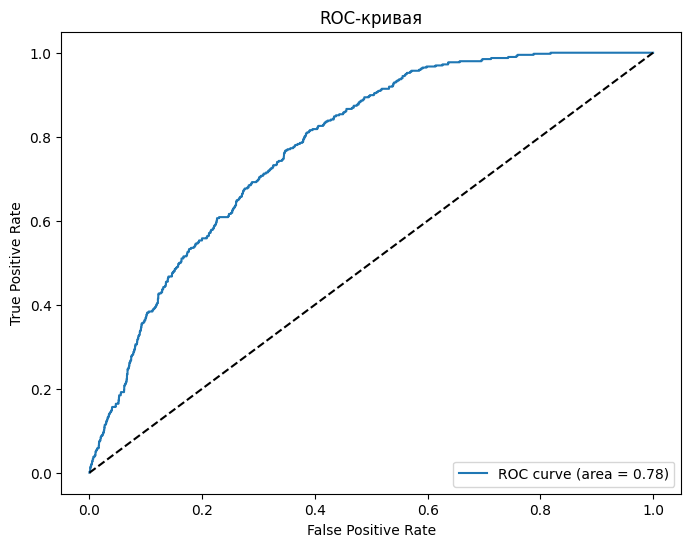

In [ ]:
from sklearn.metrics import roc_curve, auc

# Предсказания вероятностей для тестовой выборки
Y_test_prob = model.predict_proba(X_test)[:, 1]

# Расчет ROC-кривой
fpr, tpr, thresholds = roc_curve(Y_test, Y_test_prob)
roc_auc = auc(fpr, tpr)

# Построение графика
plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0,1], [0,1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC-кривая')
plt.legend(loc='lower right')
plt.show()